# 04. Ground Truth Comparison

The core result of the project: does satellite-derived visual change (RTS)
correlate with BLM's ground-measured debris density at the 33 known points?
Tested at the original buffer_m=35, then swept across 10/20/30/50m to check
whether the result depends on patch size.

**Requires:** `blm_pei_2023_latlon_final.csv` (from `01_data_preparation.ipynb`)
and `control_points_valid.csv` (from `03_control_deseasonalization.ipynb`).


## Setup

This notebook is self-contained: it re-runs Drive mounting, imports, GEE
auth, and (if needed) DINOv2 loading, so it can be run on its own without
depending on any other notebook having been run first in the same session.
Cached patches/rasters from other notebooks are still reused automatically
via the shared `CACHE_DIR`.


In [1]:
from google.colab import drive
drive.mount("/content/drive")

import os
CACHE_DIR = "/content/drive/MyDrive/burning_man_cache/patch_cache"
os.makedirs(CACHE_DIR, exist_ok=True)


Mounted at /content/drive


In [2]:
import sys
sys.path.append("/content/drive/MyDrive/burning_man_repo")

from src.gee_utils import get_patch, get_patch_cached, fetch_bulk_raster_cached
from src.features import patch_to_pil, extract_feature, extract_patch_tokens, cosine_distance, compute_patch_heatmap
from src.stats import spearman_with_bootstrap_ci, null_noise_band


In [3]:
import ee
from config import GEE_PROJECT_ID

ee.Authenticate()
ee.Initialize(project=GEE_PROJECT_ID)


In [4]:
BASELINE_START, BASELINE_END = "2023-08-01", "2023-08-20"
EVENT_START, EVENT_END = "2023-10-05", "2023-10-18"
LATE_START, LATE_END = "2023-11-01", "2023-11-20"

WINDOWS = {
    "baseline": (BASELINE_START, BASELINE_END),
    "pei_period": (EVENT_START, EVENT_END),
    "late": (LATE_START, LATE_END),
}


In [5]:
!pip install transformers torch --quiet

import torch
from transformers import AutoImageProcessor, AutoModel

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

model_name = "facebook/dinov2-base"
processor = AutoImageProcessor.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name).to(device)
model.eval()


Using device: cpu


/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
  warnings.warn(f"\nError while fetching `HF_TOKEN` secret value from your vault: '{str(e)}'.")


preprocessor_config.json:   0%|          | 0.00/436 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/548 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  346MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

Dinov2Model(
  (embeddings): Dinov2Embeddings(
    (patch_embeddings): Dinov2PatchEmbeddings(
      (projection): Conv2d(3, 768, kernel_size=(14, 14), stride=(14, 14))
    )
    (dropout): Dropout(p=0.0, inplace=False)
  )
  (encoder): Dinov2Encoder(
    (layer): ModuleList(
      (0-11): 12 x Dinov2Layer(
        (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (attention): Dinov2Attention(
          (attention): Dinov2SelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
          )
          (output): Dinov2SelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.0, inplace=False)
          )
        )
        (layer_scale1): Dinov2LayerScale()
        (drop_path): Identity()
        (norm2): LayerNorm((768,), eps=1e-06,

## Load data

Reads directly from the shared `data/` folder on Drive — no manual
upload needed, as long as `01_data_preparation.ipynb` and
`03_control_deseasonalization.ipynb` have been run at least once (their
outputs persist on Drive across sessions).


In [6]:
import pandas as pd

DATA_DIR = "/content/drive/MyDrive/burning_man_repo/data"
df = pd.read_csv(f"{DATA_DIR}/blm_pei_2023_latlon_final.csv")            # from 01_data_preparation.ipynb
valid_control_points = pd.read_csv(f"{DATA_DIR}/control_points_valid.csv")  # from 03_control_deseasonalization.ipynb

print(f"{len(df)} city points, {len(valid_control_points)} valid control points")


33 city points, 8 valid control points


## Pipeline: fetch, extract features, compute RTS, deseasonalize — for one spatial scale

Reuses `get_patch_cached` and `extract_feature`/`cosine_distance` from `src/`.
Caching means re-running this at a scale already computed in a previous
session is fast (no new GEE calls).


In [7]:
from scipy.stats import spearmanr

def run_pipeline_at_scale(buffer_m, city_df, control_df):
    city_rts = []
    for _, row in city_df.iterrows():
        baseline_patch = get_patch_cached(CACHE_DIR, row["site_id"], "baseline", row["lat"], row["lon"],
                                           *WINDOWS["baseline"], buffer_m=buffer_m)
        pei_patch = get_patch_cached(CACHE_DIR, row["site_id"], "pei_period", row["lat"], row["lon"],
                                      *WINDOWS["pei_period"], buffer_m=buffer_m)
        baseline_feat = extract_feature(baseline_patch, model, processor, device)
        pei_feat = extract_feature(pei_patch, model, processor, device)
        city_rts.append({"site_id": row["site_id"], "rts": cosine_distance(baseline_feat, pei_feat)})
    city_rts_df = pd.DataFrame(city_rts).set_index("site_id")

    control_rts = []
    for _, row in control_df.iterrows():
        baseline_patch = get_patch_cached(CACHE_DIR, row["site_id"], "baseline", row["lat"], row["lon"],
                                           *WINDOWS["baseline"], buffer_m=buffer_m)
        pei_patch = get_patch_cached(CACHE_DIR, row["site_id"], "pei_period", row["lat"], row["lon"],
                                      *WINDOWS["pei_period"], buffer_m=buffer_m)
        baseline_feat = extract_feature(baseline_patch, model, processor, device)
        pei_feat = extract_feature(pei_patch, model, processor, device)
        control_rts.append(cosine_distance(baseline_feat, pei_feat))
    control_mean = pd.Series(control_rts).mean()

    city_rts_df["rts_adj"] = city_rts_df["rts"] - control_mean

    merged = city_rts_df.join(df.set_index("site_id")[["debris_ft2_per_acre", "category"]])
    return merged, control_mean


## Run the scale sweep

`buffer_m=35` first, as the primary result and a sanity check against the
value already reported in `03` (control_mean should match ~0.180).


In [8]:
SCALES_M = [35, 10, 20, 30, 50]

scale_results = []
scale_tables = {}

for scale in SCALES_M:
    print(f"=== buffer_m = {scale} ===")
    merged, control_mean = run_pipeline_at_scale(scale, df, valid_control_points)
    scale_tables[scale] = merged

    valid = merged.dropna(subset=["rts_adj", "debris_ft2_per_acre"])
    rho, pval = spearmanr(valid["rts_adj"], valid["debris_ft2_per_acre"])

    scale_results.append({"buffer_m": scale, "control_mean": control_mean,
                           "n_points": len(valid), "spearman_rho": rho, "p_value": pval})
    print(f"  control_mean={control_mean:.3f}, rho={rho:.3f}, p={pval:.3f}, n={len(valid)}")

scale_summary = pd.DataFrame(scale_results)
scale_summary.to_csv("scale_summary.csv", index=False)
print()
print(scale_summary)


=== buffer_m = 35 ===
  control_mean=0.180, rho=0.056, p=0.758, n=33
=== buffer_m = 10 ===
  control_mean=0.143, rho=0.171, p=0.342, n=33
=== buffer_m = 20 ===
  control_mean=0.284, rho=-0.286, p=0.107, n=33
=== buffer_m = 30 ===
  control_mean=0.175, rho=-0.162, p=0.368, n=33
=== buffer_m = 50 ===
  control_mean=0.177, rho=-0.119, p=0.511, n=33

   buffer_m  control_mean  n_points  spearman_rho   p_value
0        35      0.180274        33      0.055839  0.757594
1        10      0.143259        33      0.170693  0.342243
2        20      0.284294        33     -0.285714  0.107001
3        30      0.175100        33     -0.162000  0.367746
4        50      0.177234        33     -0.118699  0.510592


## Bootstrap confidence interval for the primary result (buffer_m=35)

Supplements the p-value with a resampling-based CI on rho itself.


In [9]:
primary = scale_tables[35].dropna(subset=["rts_adj", "debris_ft2_per_acre"])
result = spearman_with_bootstrap_ci(primary["rts_adj"], primary["debris_ft2_per_acre"])
print(f"rho={result['rho']:.3f}, p={result['p_value']:.3f}, "
      f"95% CI=[{result['ci_lower']:.3f}, {result['ci_upper']:.3f}], n={result['n']}")


rho=0.056, p=0.758, 95% CI=[-0.308, 0.397], n=33


## Plot: correlation across spatial scales, against the null-noise band

The shaded band is the range of rho values expected under pure sampling
noise at n=33, if the true correlation were exactly 0. All 5 scale estimates
fall inside it.


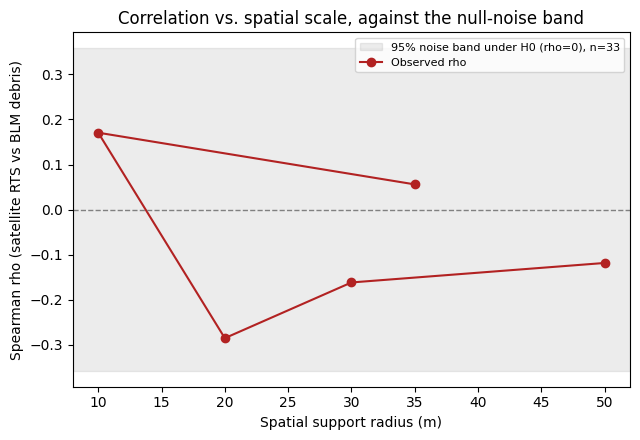

In [10]:
import matplotlib.pyplot as plt

ci_half_width = null_noise_band(n=scale_summary["n_points"].iloc[0])

plt.figure(figsize=(6.5, 4.5))
plt.axhspan(-ci_half_width, ci_half_width, color="gray", alpha=0.15,
            label=f"95% noise band under H0 (rho=0), n={scale_summary['n_points'].iloc[0]}")
plt.plot(scale_summary["buffer_m"], scale_summary["spearman_rho"], "o-", color="firebrick",
         label="Observed rho")
plt.axhline(0, color="gray", linestyle="--", linewidth=1)
plt.xlabel("Spatial support radius (m)")
plt.ylabel("Spearman rho (satellite RTS vs BLM debris)")
plt.title("Correlation vs. spatial scale, against the null-noise band")
plt.legend(loc="upper right", fontsize=8)
plt.tight_layout()
plt.savefig("scale_sensitivity_with_band.png", dpi=150)
plt.show()


## Plot: primary scatter (buffer_m=35)

The main result figure: RTS_adj vs. BLM debris density at the original
patch size.


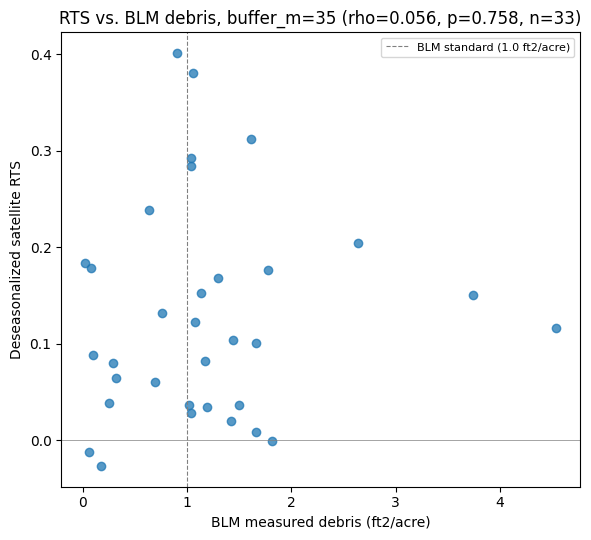

In [11]:
plt.figure(figsize=(6, 5.5))
plt.scatter(primary["debris_ft2_per_acre"], primary["rts_adj"], alpha=0.75)
plt.axhline(0, color="gray", linewidth=0.5)
plt.axvline(1.0, color="gray", linestyle="--", linewidth=0.8, label="BLM standard (1.0 ft2/acre)")
plt.xlabel("BLM measured debris (ft2/acre)")
plt.ylabel("Deseasonalized satellite RTS")
plt.title(f"RTS vs. BLM debris, buffer_m=35 (rho={result['rho']:.3f}, p={result['p_value']:.3f}, n={result['n']})")
plt.legend(fontsize=8)
plt.tight_layout()
plt.savefig("rts_vs_debris_scatter.png", dpi=150)
plt.show()
